<div style="text-align: center; line-height: 1.35;">
  <h3><strong>UNIVERSIDAD TECNOLÓGICA DE PANAMÁ</strong></h3>
  <h3>FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
  <h3>DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
  <hr style="margin: 24px 0;">
  <h1><strong>Taller Práctico N.° 5</strong></h1>
  <h2>Optimización Lineal con PuLP</h2>
  <h3>Investigación de Operaciones</h3>
</div>

| Campo | Información |
|---|---|
| Asistente utilizado para realizar el taller | CodeX |
| Integrante 1 | [Terry He ] |
| Integrante 2 | [Kevin Morales] |
| Integrante 3 | [Jhuomar Barría] |

## Objetivo general

Formular y resolver tres problemas de optimización lineal con enfoque de Investigación de Operaciones, interpretando la función objetivo, las restricciones y el significado operativo de las variables de decisión en cada caso.


In [1]:
# Instalación e importación de librerías.
# Se usa %pip para asegurar que PuLP quede disponible en el mismo entorno del kernel.
%pip install pulp pandas matplotlib seaborn

import pandas as pd
import pulp
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

# El estilo visual se ajusta para que las gráficas sean limpias y consistentes.
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Se utiliza el solver CBC que viene integrado con PuLP.
solver = pulp.PULP_CBC_CMD(msg=False)


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Función auxiliar para reportar estados y resultados de forma homogénea.
# Centralizar este bloque evita repetir la lógica de validación en cada problema.
def report_solution(problem, variables, objective_label):
    status = pulp.LpStatus[problem.status]
    print(f'Estado del solver: {status}')

    if status == 'Optimal':
        objective_value = pulp.value(problem.objective)
        print(f'Valor óptimo de {objective_label}: {objective_value:,.4f}')

        rows = []
        for name, var in variables.items():
            rows.append({'Variable': name, 'Valor': var.value()})

        df = pd.DataFrame(rows)
        display(df)
        return df

    if status == 'Infeasible':
        print('El modelo es infactible: no existe una solución que satisfaga simultáneamente todas las restricciones.')
    elif status == 'Unbounded':
        print('El modelo no está acotado: la función objetivo puede mejorar sin límite bajo la formulación actual.')
    else:
        print('El solver no alcanzó una solución óptima. Conviene revisar la estructura matemática del modelo.')

    return None



## Problema 1: Transporte de mercancías con costo mínimo

**Origen:** Generado.

### 1. Contexto del problema

Una empresa logística debe abastecer tres centros de distribución desde dos plantas de producción. Cada ruta planta-centro tiene un costo unitario distinto, y la decisión consiste en determinar cuántas unidades enviar por cada ruta para minimizar el costo total de transporte.

El caso justifica el uso de programación lineal porque el costo total se representa como una combinación lineal de las cantidades enviadas, y las restricciones de oferta y demanda también son lineales.

**Datos del problema**

| Origen / Destino | Centro 1 | Centro 2 | Centro 3 | Oferta |
|---|---:|---:|---:|---:|
| Planta A | 8 | 6 | 10 | 35 |
| Planta B | 9 | 12 | 13 | 40 |
| **Demanda** | **20** | **30** | **25** | |

### 2. Objetivo del problema

Minimizar el costo total de transporte cumpliendo exactamente la oferta disponible y la demanda requerida.

### 3. Variables de decisión

- $x_{ij}$: unidades enviadas desde la planta $i$ al centro $j$.
- Dominio: variable continua no negativa.

### 4. Parámetros del modelo

- $c_{ij}$: costo unitario de envío desde la planta $i$ al centro $j$.
- $s_i$: oferta disponible en la planta $i$.
- $d_j$: demanda requerida por el centro $j$.

### 5. Función objetivo

$$
\begin{aligned}
\min\; Z &= 8x_{A1} + 6x_{A2} + 10x_{A3} + 9x_{B1} + 12x_{B2} + 13x_{B3}
\end{aligned}
$$

### 6. Restricciones

$$
\begin{aligned}
x_{A1} + x_{A2} + x_{A3} &= 35 \\
x_{B1} + x_{B2} + x_{B3} &= 40 \\
x_{A1} + x_{B1} &= 20 \\
x_{A2} + x_{B2} &= 30 \\
x_{A3} + x_{B3} &= 25
\end{aligned}
$$

### 7. Condiciones sobre las variables

$$
x_{ij} \ge 0
$$

### 8. Formulación matemática completa

$$
\begin{aligned}
\min\; Z &= \sum_{i \in \{A,B\}} \sum_{j \in \{1,2,3\}} c_{ij}x_{ij} \\
\text{s.a.}\quad \sum_{j \in \{1,2,3\}} x_{Aj} &= 35 \\
\sum_{j \in \{1,2,3\}} x_{Bj} &= 40 \\
\sum_{i \in \{A,B\}} x_{i1} &= 20 \\
\sum_{i \in \{A,B\}} x_{i2} &= 30 \\
\sum_{i \in \{A,B\}} x_{i3} &= 25 \\
x_{ij} &\ge 0
\end{aligned}
$$

### 9. Implementación en PuLP

La construcción computacional del modelo aparece en la siguiente celda. Allí se define el problema, se crean las variables, se formula la función objetivo y se agregan las restricciones.

### 10. Resultados

La celda de código mostrará el estado del solver, el valor óptimo de la función objetivo y los valores de las variables de decisión.

### 11. Interpretación de la solución

La solución óptima indica la combinación de rutas que satisface exactamente la oferta y la demanda al menor costo posible. La matriz de envíos permite verificar visualmente qué rutas se utilizan y cuáles quedan en cero.

### 12. Calidad del modelo

El modelo es lineal, balanceado y consistente: las restricciones no se contradicen entre sí y la solución reportada por PuLP puede interpretarse operativamente en el contexto logístico.


,Centro 1,Centro 2,Centro 3
Planta A,8,6,10
Planta B,9,12,13


Estado del solver: Optimal
Costo óptimo de transporte: 670.00


,Centro 1,Centro 2,Centro 3
Planta A,0.00,30.00,5.00
Planta B,20.00,0.00,20.00


,Origen,Destino,Unidades
0,Planta A,Centro 2,30.00
1,Planta A,Centro 3,5.00
2,Planta B,Centro 1,20.00
3,Planta B,Centro 3,20.00


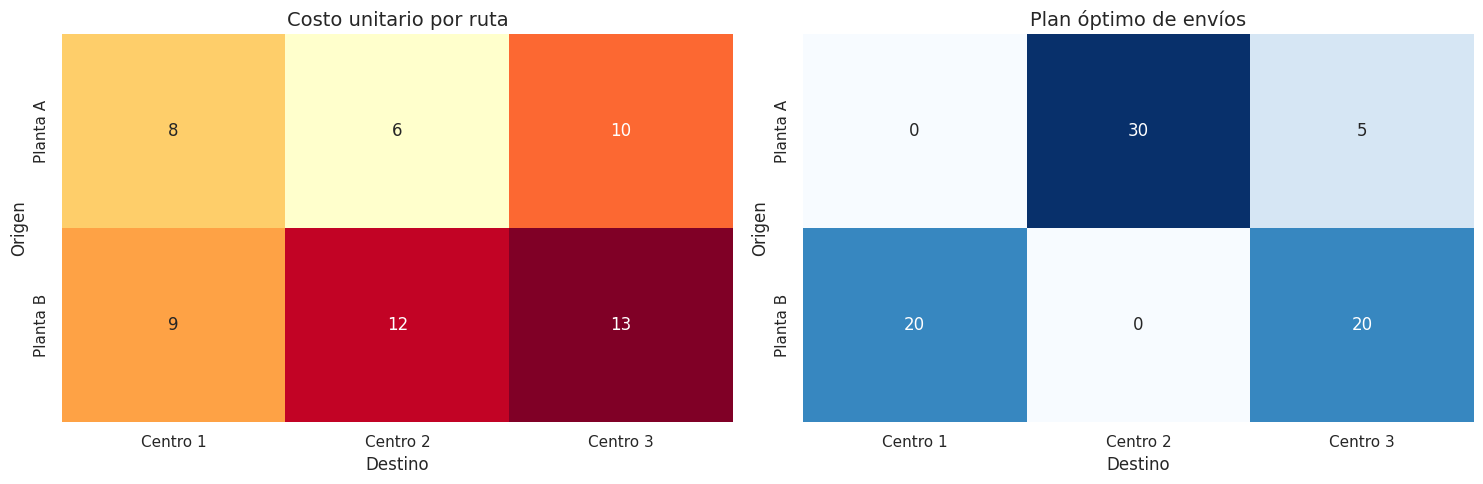

Estado del solver: Optimal
Valor óptimo de el costo total de transporte: 670.0000


,Variable,Valor
0,Envio_Planta_A_Centro_1,0.00
1,Envio_Planta_A_Centro_2,30.00
2,Envio_Planta_A_Centro_3,5.00
3,Envio_Planta_B_Centro_1,20.00
4,Envio_Planta_B_Centro_2,0.00
5,Envio_Planta_B_Centro_3,20.00


,Variable,Valor
0,Envio_Planta_A_Centro_1,0.00
1,Envio_Planta_A_Centro_2,30.00
2,Envio_Planta_A_Centro_3,5.00
3,Envio_Planta_B_Centro_1,20.00
4,Envio_Planta_B_Centro_2,0.00
5,Envio_Planta_B_Centro_3,20.00


In [3]:
# Problema 1: modelo de transporte de costo mínimo.

plantas = ['Planta A', 'Planta B']
centros = ['Centro 1', 'Centro 2', 'Centro 3']

oferta = {
    'Planta A': 35,
    'Planta B': 40,
}

demanda = {
    'Centro 1': 20,
    'Centro 2': 30,
    'Centro 3': 25,
}

# La matriz de costos resume el gasto por unidad transportada en cada ruta.
costos_transporte = pd.DataFrame(
    [[8, 6, 10],
     [9, 12, 13]],
    index=plantas,
    columns=centros,
)

display(costos_transporte)

prob1 = pulp.LpProblem('Problema_1_Transporte_Minimo_Costo', pulp.LpMinimize)

# Variables no negativas: no tiene sentido físico enviar cantidades negativas.
# No se fijan cotas superiores porque los límites reales ya los imponen oferta y demanda.
x = pulp.LpVariable.dicts('Envio', (plantas, centros), lowBound=0, cat='Continuous')

# Función objetivo: suma de costo unitario por cantidad enviada en cada arco de la red.
prob1 += pulp.lpSum(costos_transporte.loc[i, j] * x[i][j] for i in plantas for j in centros), 'Costo_Total_Transporte'

# Restricciones de oferta: cada planta despacha exactamente lo que produce o dispone.
for i in plantas:
    prob1 += pulp.lpSum(x[i][j] for j in centros) == oferta[i], f'Oferta_{i}'

# Restricciones de demanda: cada centro recibe exactamente lo que necesita.
for j in centros:
    prob1 += pulp.lpSum(x[i][j] for i in plantas) == demanda[j], f'Demanda_{j}'

# Resolución del modelo.
prob1.solve(solver)

estado1 = pulp.LpStatus[prob1.status]
print('Estado del solver:', estado1)

if estado1 == 'Optimal':
    print(f'Costo óptimo de transporte: {pulp.value(prob1.objective):,.2f}')

    shipment_df = pd.DataFrame(
        [[pulp.value(x[i][j]) for j in centros] for i in plantas],
        index=plantas,
        columns=centros,
    )

    display(shipment_df)

    rutas = []
    for i in plantas:
        for j in centros:
            valor = pulp.value(x[i][j])
            if valor > 1e-6:
                rutas.append({'Origen': i, 'Destino': j, 'Unidades': valor})
    display(pd.DataFrame(rutas))

    # Gráficas acordes al problema: un mapa de costos y un mapa del plan óptimo.
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(costos_transporte, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False, ax=axes[0])
    axes[0].set_title('Costo unitario por ruta')
    axes[0].set_xlabel('Destino')
    axes[0].set_ylabel('Origen')

    sns.heatmap(shipment_df, annot=True, fmt='.0f', cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title('Plan óptimo de envíos')
    axes[1].set_xlabel('Destino')
    axes[1].set_ylabel('Origen')

    plt.tight_layout()
    plt.show()

report_solution(
    prob1,
    {
        'Envio_Planta_A_Centro_1': x['Planta A']['Centro 1'],
        'Envio_Planta_A_Centro_2': x['Planta A']['Centro 2'],
        'Envio_Planta_A_Centro_3': x['Planta A']['Centro 3'],
        'Envio_Planta_B_Centro_1': x['Planta B']['Centro 1'],
        'Envio_Planta_B_Centro_2': x['Planta B']['Centro 2'],
        'Envio_Planta_B_Centro_3': x['Planta B']['Centro 3'],
    },
    'el costo total de transporte',
)



## Problema 2: Presupuesto de capital para seleccionar proyectos

**Origen:** Generado.

### 1. Contexto del problema

Una organización dispone de un conjunto de proyectos de inversión y debe decidir cuáles financiar durante el próximo periodo. Cada proyecto tiene un costo inicial, una contribución económica estimada medida como valor actual neto (VAN) y una carga de trabajo en horas de personal. Además, la gerencia solo puede aprobar un máximo de tres proyectos.

El caso es apropiado para programación lineal entera binaria porque la decisión de invertir en un proyecto es discreta: se aprueba completamente o no se aprueba.

**Datos del problema**

| Proyecto | VAN | Costo | Horas requeridas |
|---|---:|---:|---:|
| P1 | 18 | 10 | 4 |
| P2 | 24 | 12 | 5 |
| P3 | 15 | 8 | 3 |
| P4 | 28 | 14 | 6 |
| P5 | 20 | 11 | 4 |

Recursos disponibles:

- Presupuesto máximo: 30 unidades monetarias.
- Horas máximas del equipo: 13 horas.
- Máximo de proyectos seleccionables: 3.

### 2. Objetivo del problema

Maximizar el VAN total de la cartera de proyectos respetando simultáneamente el presupuesto, la capacidad de horas del equipo y el límite gerencial de proyectos.

### 3. Variables de decisión

- $x_k$: vale 1 si el proyecto $k$ se selecciona y 0 en caso contrario.
- Dominio: variables binarias.

### 4. Parámetros del modelo

- $v_k$: VAN asociado al proyecto $k$.
- $c_k$: costo de inversión del proyecto $k$.
- $h_k$: horas requeridas por el proyecto $k$.
- $B$: presupuesto total disponible.
- $H$: horas máximas disponibles del equipo.
- $K$: número máximo de proyectos seleccionables.

### 5. Función objetivo

$$
\begin{aligned}
\max\; Z &= 18x_1 + 24x_2 + 15x_3 + 28x_4 + 20x_5
\end{aligned}
$$

### 6. Restricciones

$$
\begin{aligned}
10x_1 + 12x_2 + 8x_3 + 14x_4 + 11x_5 &\le 30 \\
4x_1 + 5x_2 + 3x_3 + 6x_4 + 4x_5 &\le 13 \\
x_1 + x_2 + x_3 + x_4 + x_5 &\le 3
\end{aligned}
$$

### 7. Condiciones sobre las variables

$$
x_k \in \{0,1\}
$$

### 8. Formulación matemática completa

$$
\begin{aligned}
\max\; Z &= \sum_{k=1}^{5} v_k x_k \\
\text{s.a.}\quad \sum_{k=1}^{5} c_k x_k &\le B \\
\sum_{k=1}^{5} h_k x_k &\le H \\
\sum_{k=1}^{5} x_k &\le K \\
x_k &\in \{0,1\}
\end{aligned}
$$

### 9. Implementación en PuLP

La celda de código siguiente traduce la formulación matemática al modelo computacional y ejecuta el solver.

### 10. Resultados

Se reportará el estado de la solución, el VAN óptimo y la selección binaria de cada proyecto.

### 11. Interpretación de la solución

La solución óptima identifica qué proyectos conviene aprobar para maximizar el valor económico total bajo las limitaciones operativas. Además, permite verificar el uso de presupuesto y horas del equipo.

### 12. Calidad del modelo

El modelo es lineal, factible y consistente. La binariedad de las variables refleja correctamente la naturaleza discreta de la decisión de inversión.


,Proyecto,VAN,Costo,Horas
0,P1,18,10,4
1,P2,24,12,5
2,P3,15,8,3
3,P4,28,14,6
4,P5,20,11,4


Estado del solver: Optimal
VAN óptimo de la cartera: 57.00


,Proyecto,VAN,Costo,Horas,Seleccionado
0,P1,18,10,4,1
1,P2,24,12,5,1
2,P3,15,8,3,1
3,P4,28,14,6,0
4,P5,20,11,4,0


Proyectos seleccionados: P1, P2, P3
Presupuesto usado: 30.00 de 30.00
Horas usadas: 12.00 de 13.00


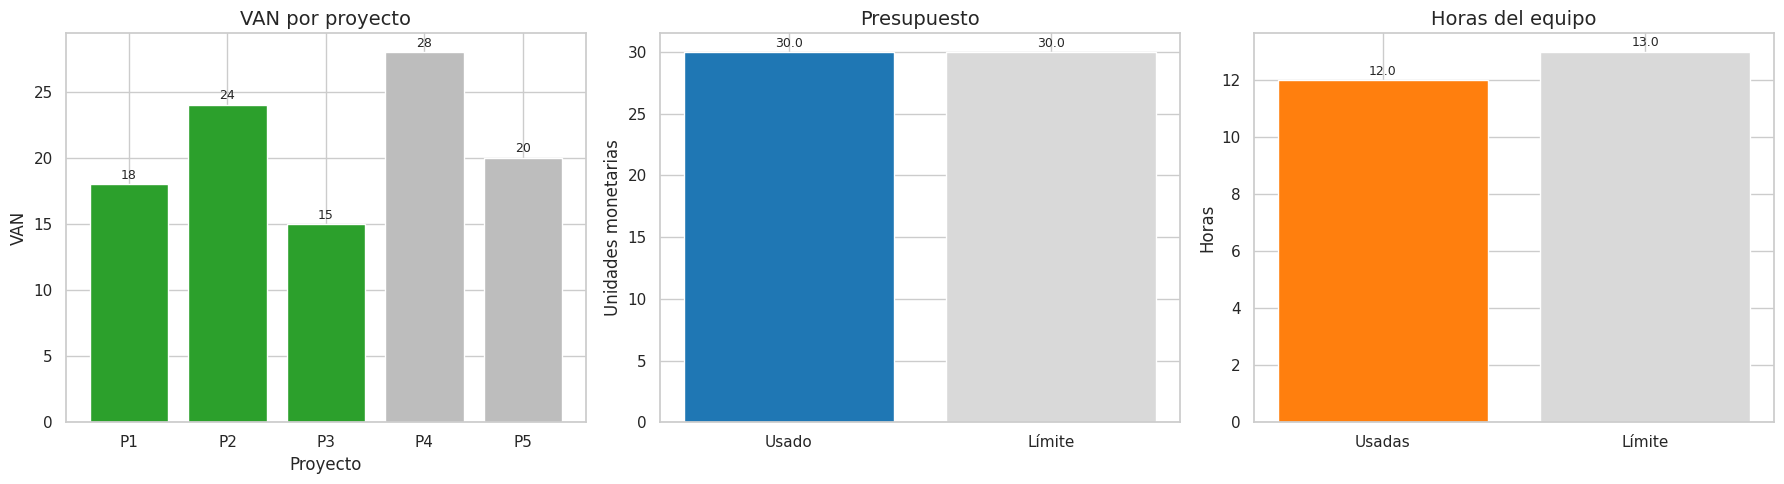

Estado del solver: Optimal
Valor óptimo de el VAN total de la cartera: 57.0000


,Variable,Valor
0,Seleccion_P1,1.00
1,Seleccion_P2,1.00
2,Seleccion_P3,1.00
3,Seleccion_P4,0.00
4,Seleccion_P5,0.00


,Variable,Valor
0,Seleccion_P1,1.00
1,Seleccion_P2,1.00
2,Seleccion_P3,1.00
3,Seleccion_P4,0.00
4,Seleccion_P5,0.00


In [4]:
# Problema 2: modelo de selección de proyectos con variables binarias.

proyectos = ['P1', 'P2', 'P3', 'P4', 'P5']

# Los valores económicos se expresan en una unidad homogénea para mantener la linealidad.
van = {
    'P1': 18,
    'P2': 24,
    'P3': 15,
    'P4': 28,
    'P5': 20,
}

costo = {
    'P1': 10,
    'P2': 12,
    'P3': 8,
    'P4': 14,
    'P5': 11,
}

horas = {
    'P1': 4,
    'P2': 5,
    'P3': 3,
    'P4': 6,
    'P5': 4,
}

presupuesto_maximo = 30
horas_maximas = 13
max_proyectos = 3

datos_proyectos = pd.DataFrame(
    {
        'Proyecto': proyectos,
        'VAN': [van[p] for p in proyectos],
        'Costo': [costo[p] for p in proyectos],
        'Horas': [horas[p] for p in proyectos],
    }
)
display(datos_proyectos)

prob2 = pulp.LpProblem('Problema_2_Presupuesto_Capital', pulp.LpMaximize)

# Variables binarias: 0 o 1, porque un proyecto se financia completamente o no se financia.
# Los límites 0 y 1 refuerzan la interpretación lógica de la decisión.
x = pulp.LpVariable.dicts('Seleccion', proyectos, lowBound=0, upBound=1, cat='Binary')

# Función objetivo: suma del VAN ponderado por la decisión de selección.
prob2 += pulp.lpSum(van[p] * x[p] for p in proyectos), 'VAN_Total'

# Restricción de presupuesto: no se puede superar la inversión disponible.
prob2 += pulp.lpSum(costo[p] * x[p] for p in proyectos) <= presupuesto_maximo, 'Presupuesto'

# Restricción de horas: el equipo tiene capacidad operativa limitada.
prob2 += pulp.lpSum(horas[p] * x[p] for p in proyectos) <= horas_maximas, 'Horas_Equipo'

# Restricción gerencial: no más de tres proyectos en la cartera.
prob2 += pulp.lpSum(x[p] for p in proyectos) <= max_proyectos, 'Limite_Proyectos'

# Resolución del modelo.
prob2.solve(solver)

estado2 = pulp.LpStatus[prob2.status]
print('Estado del solver:', estado2)

if estado2 == 'Optimal':
    print(f'VAN óptimo de la cartera: {pulp.value(prob2.objective):,.2f}')

    seleccion_df = pd.DataFrame(
        {
            'Proyecto': proyectos,
            'VAN': [van[p] for p in proyectos],
            'Costo': [costo[p] for p in proyectos],
            'Horas': [horas[p] for p in proyectos],
            'Seleccionado': [int(round(pulp.value(x[p]))) for p in proyectos],
        }
    )
    display(seleccion_df)

    seleccionados = [p for p in proyectos if pulp.value(x[p]) > 0.5]
    costo_usado = sum(costo[p] * pulp.value(x[p]) for p in proyectos)
    horas_usadas = sum(horas[p] * pulp.value(x[p]) for p in proyectos)
    print('Proyectos seleccionados:', ', '.join(seleccionados) if seleccionados else 'Ninguno')
    print(f'Presupuesto usado: {costo_usado:,.2f} de {presupuesto_maximo:,.2f}')
    print(f'Horas usadas: {horas_usadas:,.2f} de {horas_maximas:,.2f}')

    # Gráficas: VAN por proyecto y utilización de recursos.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colores = ['#2ca02c' if int(round(pulp.value(x[p]))) == 1 else '#bdbdbd' for p in proyectos]
    axes[0].bar(proyectos, [van[p] for p in proyectos], color=colores)
    axes[0].set_title('VAN por proyecto')
    axes[0].set_xlabel('Proyecto')
    axes[0].set_ylabel('VAN')
    for idx, p in enumerate(proyectos):
        axes[0].text(idx, van[p] + 0.4, f"{van[p]}", ha='center', fontsize=9)

    axes[1].bar(['Usado', 'Límite'], [costo_usado, presupuesto_maximo], color=['#1f77b4', '#d9d9d9'])
    axes[1].set_title('Presupuesto')
    axes[1].set_ylabel('Unidades monetarias')
    for idx, value in enumerate([costo_usado, presupuesto_maximo]):
        axes[1].text(idx, value + 0.4, f'{value:,.1f}', ha='center', fontsize=9)

    axes[2].bar(['Usadas', 'Límite'], [horas_usadas, horas_maximas], color=['#ff7f0e', '#d9d9d9'])
    axes[2].set_title('Horas del equipo')
    axes[2].set_ylabel('Horas')
    for idx, value in enumerate([horas_usadas, horas_maximas]):
        axes[2].text(idx, value + 0.2, f'{value:,.1f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

report_solution(
    prob2,
    {
        'Seleccion_P1': x['P1'],
        'Seleccion_P2': x['P2'],
        'Seleccion_P3': x['P3'],
        'Seleccion_P4': x['P4'],
        'Seleccion_P5': x['P5'],
    },
    'el VAN total de la cartera',
)



## Problema 3: Planificación agregada de producción con inventarios

**Origen:** Generado.

### 1. Contexto del problema

Una planta manufacturera debe cumplir la demanda de tres periodos consecutivos. En cada periodo puede producir hasta una capacidad máxima diferente, pero producir demasiado en un periodo y no consumirlo de inmediato genera inventario, y por tanto un costo de almacenamiento.

El caso modela una decisión de planeación agregada, donde el sistema combina flujo de producción e inventario. La estructura es lineal porque los costos, balances y límites de capacidad se expresan mediante ecuaciones lineales.

**Datos del problema**

| Periodo | Demanda | Capacidad | Costo de producción | Costo de inventario |
|---|---:|---:|---:|---:|
| 1 | 40 | 60 | 20 | 2 |
| 2 | 50 | 40 | 22 | 2 |
| 3 | 45 | 55 | 21 | 2 |

Condiciones iniciales y de cierre:

- Inventario inicial: 10 unidades.
- Inventario final requerido: 5 unidades.

### 2. Objetivo del problema

Minimizar el costo total de producción y almacenamiento, garantizando la satisfacción de la demanda y el inventario final requerido.

### 3. Variables de decisión

- $p_t$: unidades producidas en el periodo $t$.
- $I_t$: inventario al final del periodo $t$.
- Dominio: variables continuas no negativas.

### 4. Parámetros del modelo

- $d_t$: demanda del periodo $t$.
- $u_t$: capacidad máxima de producción en el periodo $t$.
- $c_t$: costo unitario de producción en el periodo $t$.
- $h$: costo unitario de inventario.
- $I_0$: inventario inicial.
- $I_3^*$: inventario final requerido.

### 5. Función objetivo

$$
\begin{aligned}
\min\; Z &= 20p_1 + 22p_2 + 21p_3 + 2I_1 + 2I_2 + 2I_3
\end{aligned}
$$

### 6. Restricciones

$$
\begin{aligned}
I_0 + p_1 - d_1 &= I_1 \\
I_1 + p_2 - d_2 &= I_2 \\
I_2 + p_3 - d_3 &= I_3 \\
I_3 &= 5 \\
p_1 &\le 60 \\
p_2 &\le 40 \\
p_3 &\le 55
\end{aligned}
$$

### 7. Condiciones sobre las variables

$$
p_t \ge 0, \quad I_t \ge 0
$$

### 8. Formulación matemática completa

$$
\begin{aligned}
\min\; Z &= \sum_{t=1}^{3} c_t p_t + h\sum_{t=1}^{3} I_t \\
\text{s.a.}\quad I_{t-1} + p_t - d_t &= I_t, \quad t=1,2,3 \\
I_3 &= I_3^* \\
p_t &\le u_t, \quad t=1,2,3 \\
p_t, I_t &\ge 0
\end{aligned}
$$

### 9. Implementación en PuLP

La siguiente celda construye el problema, define variables de producción e inventario, añade el balance de flujo y resuelve el modelo.

### 10. Resultados

La salida del solver mostrará el estado del problema, el costo óptimo y los valores de producción e inventario por periodo.

### 11. Interpretación de la solución

La solución óptima distribuye la producción entre los tres periodos para satisfacer la demanda y cerrar con el inventario requerido al menor costo posible. El modelo muestra cómo usar capacidad y stock de manera eficiente para evitar sobrecostos innecesarios.

### 12. Calidad del modelo

El modelo es lineal, factible y consistente. Las restricciones de balance garantizan conservación de flujo y las capacidades acotan correctamente la producción.


,Periodo,Demanda,Capacidad,Costo produccion
0,1,40,60,20
1,2,50,40,22
2,3,45,55,21


Estado del solver: Optimal
Costo óptimo de planeación: 2,760.00


,Periodo,Demanda,Capacidad,Produccion_optima,Inventario_final
0,1,40,60,40.00,10.00
1,2,50,40,40.00,0.00
2,3,45,55,50.00,5.00


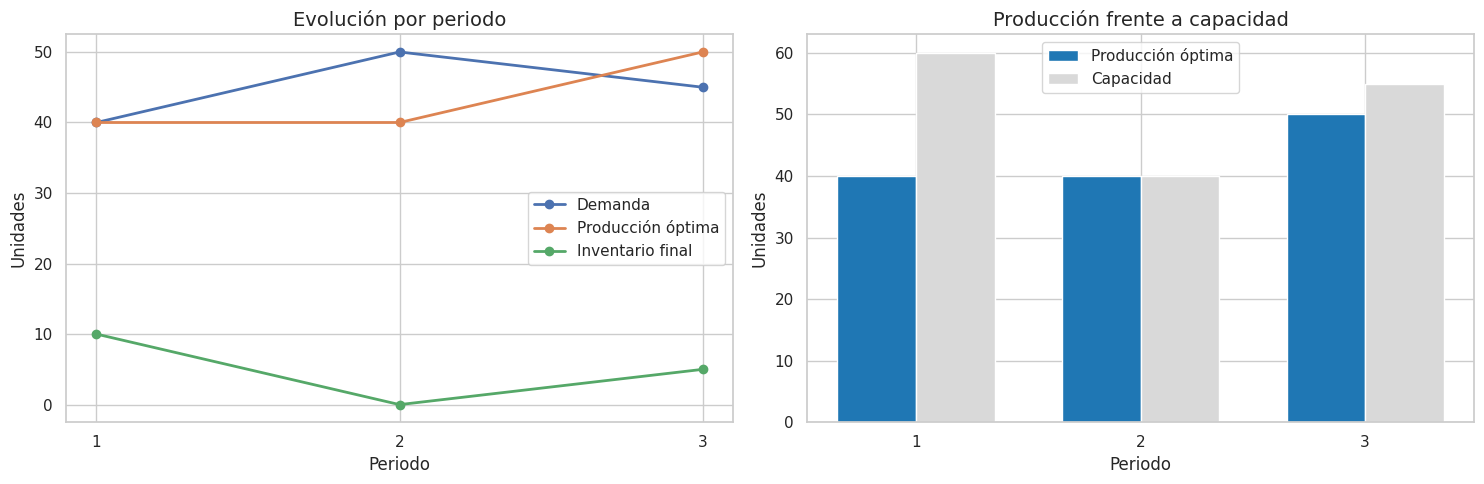

Estado del solver: Optimal
Valor óptimo de el costo total de planeación: 2,760.0000


,Variable,Valor
0,Produccion_Periodo_1,40.00
1,Produccion_Periodo_2,40.00
2,Produccion_Periodo_3,50.00
3,Inventario_Periodo_1,10.00
4,Inventario_Periodo_2,0.00
5,Inventario_Periodo_3,5.00


,Variable,Valor
0,Produccion_Periodo_1,40.00
1,Produccion_Periodo_2,40.00
2,Produccion_Periodo_3,50.00
3,Inventario_Periodo_1,10.00
4,Inventario_Periodo_2,0.00
5,Inventario_Periodo_3,5.00


In [5]:
# Problema 3: modelo de planeación agregada de producción con inventario.

periodos = [1, 2, 3]

demanda = {
    1: 40,
    2: 50,
    3: 45,
}

capacidad = {
    1: 60,
    2: 40,
    3: 55,
}

costo_produccion = {
    1: 20,
    2: 22,
    3: 21,
}

costo_inventario = 2
inventario_inicial = 10
inventario_final_requerido = 5

datos_plan = pd.DataFrame(
    {
        'Periodo': periodos,
        'Demanda': [demanda[t] for t in periodos],
        'Capacidad': [capacidad[t] for t in periodos],
        'Costo produccion': [costo_produccion[t] for t in periodos],
    }
)
display(datos_plan)

prob3 = pulp.LpProblem('Problema_3_Planeacion_Produccion', pulp.LpMinimize)

# Variables continuas no negativas: la producción y el inventario no pueden ser negativos.
# No se coloca cota superior al inventario porque ya queda inducida por la dinámica del sistema.
produccion = pulp.LpVariable.dicts('Produccion', periodos, lowBound=0, cat='Continuous')
inventario = pulp.LpVariable.dicts('Inventario', periodos, lowBound=0, cat='Continuous')

# Función objetivo: costos de fabricación más costos de mantener inventario.
prob3 += pulp.lpSum(costo_produccion[t] * produccion[t] + costo_inventario * inventario[t] for t in periodos), 'Costo_Total_Planeacion'

# Balance del primer periodo: inventario inicial + producción - demanda = inventario final del periodo.
prob3 += inventario_inicial + produccion[1] - demanda[1] == inventario[1], 'Balance_Periodo_1'

# Balances interperiodo: el inventario de cierre de un periodo se convierte en inventario inicial del siguiente.
for t in periodos[1:]:
    prob3 += inventario[t - 1] + produccion[t] - demanda[t] == inventario[t], f'Balance_Periodo_{t}'

# Capacidad productiva por periodo: cada máquina o línea tiene un techo operativo.
for t in periodos:
    prob3 += produccion[t] <= capacidad[t], f'Capacidad_Periodo_{t}'

# Requisito de cierre: la planta debe terminar con el inventario estratégico solicitado.
prob3 += inventario[3] == inventario_final_requerido, 'Inventario_Final_Requerido'

# Resolución del modelo.
prob3.solve(solver)

estado3 = pulp.LpStatus[prob3.status]
print('Estado del solver:', estado3)

if estado3 == 'Optimal':
    print(f'Costo óptimo de planeación: {pulp.value(prob3.objective):,.2f}')

    plan_df = pd.DataFrame(
        {
            'Periodo': periodos,
            'Demanda': [demanda[t] for t in periodos],
            'Capacidad': [capacidad[t] for t in periodos],
            'Produccion_optima': [pulp.value(produccion[t]) for t in periodos],
            'Inventario_final': [pulp.value(inventario[t]) for t in periodos],
        }
    )
    display(plan_df)

    # Gráficas: dinámica temporal de producción, demanda e inventario, más comparación con capacidad.
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(periodos, [demanda[t] for t in periodos], marker='o', linewidth=2, label='Demanda')
    axes[0].plot(periodos, [pulp.value(produccion[t]) for t in periodos], marker='o', linewidth=2, label='Producción óptima')
    axes[0].plot(periodos, [pulp.value(inventario[t]) for t in periodos], marker='o', linewidth=2, label='Inventario final')
    axes[0].set_title('Evolución por periodo')
    axes[0].set_xlabel('Periodo')
    axes[0].set_ylabel('Unidades')
    axes[0].set_xticks(periodos)
    axes[0].legend()

    ancho = 0.35
    posiciones = list(range(len(periodos)))
    producciones = [pulp.value(produccion[t]) for t in periodos]
    capacidades = [capacidad[t] for t in periodos]

    axes[1].bar([p - ancho / 2 for p in posiciones], producciones, width=ancho, label='Producción óptima', color='#1f77b4')
    axes[1].bar([p + ancho / 2 for p in posiciones], capacidades, width=ancho, label='Capacidad', color='#d9d9d9')
    axes[1].set_title('Producción frente a capacidad')
    axes[1].set_xlabel('Periodo')
    axes[1].set_ylabel('Unidades')
    axes[1].set_xticks(posiciones)
    axes[1].set_xticklabels([str(t) for t in periodos])
    axes[1].legend()

    plt.tight_layout()
    plt.show()

report_solution(
    prob3,
    {
        'Produccion_Periodo_1': produccion[1],
        'Produccion_Periodo_2': produccion[2],
        'Produccion_Periodo_3': produccion[3],
        'Inventario_Periodo_1': inventario[1],
        'Inventario_Periodo_2': inventario[2],
        'Inventario_Periodo_3': inventario[3],
    },
    'el costo total de planeación',
)


## Cierre

En este taller se desarrollaron tres modelos lineales distintos: transporte de mercancías, selección de proyectos y planeación agregada de producción. Cada uno fue formulado desde su interpretación operativa, resuelto con PuLP y complementado con gráficas que facilitan la lectura de los resultados.


